<a href="https://colab.research.google.com/github/Vedangi914/Vedangi/blob/main/notebook5b646f1b64.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

vedangisolanki9_dataset1_path = kagglehub.dataset_download('vedangisolanki9/dataset1')
vedangisolanki9_dataset2_path = kagglehub.dataset_download('vedangisolanki9/dataset2')
vedangisolanki9_dataset3_path = kagglehub.dataset_download('vedangisolanki9/dataset3')

print('Data source import complete.')


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/vedangisolanki9/dataset1/Dropper.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/NoCategory.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Backdoor.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/PUA.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Scareware.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/FileInfector.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Adware.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Zeroday.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/SMS.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Spy.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Trojan.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Banker.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Ransomware.csv
/kaggle/input/datasets/vedangisolanki9/dataset1/Riskware.csv
/kaggle/input/datasets/vedangisolanki9/dataset3/Scareware_before_reboot_Cat.csv
/kaggle/input/datasets/vedangisolanki9/dataset3/Backdoor_before_reboot_Cat.csv
/

In [ ]:
adware = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset1/Adware.csv',
    nrows=1000
)

trojan = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset1/Trojan.csv',
    nrows=1000
)

ransomware = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset1/Ransomware.csv',
    nrows=1500
)

spyware = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset1/Spy.csv',
    nrows=2000
)

backdoor = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset1/Backdoor.csv',
    nrows=2000
)

ben0 = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset2/Ben0.csv',
    nrows=1000
)

ben1 = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset2/Ben1.csv',
    nrows=1000
)

ben2 = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset2/Ben2.csv',
    nrows=1000
)

ben3 = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset2/Ben3.csv',
    nrows=1000
)

ben4 = pd.read_csv(
    '/kaggle/input/datasets/vedangisolanki9/dataset2/Ben4.csv',
    nrows=1000
)

In [ ]:
adware['label'] = 0

trojan['label'] = 1

ransomware['label'] = 2

spyware['label'] = 3

backdoor['label'] = 4

ben0['label'] = 5
ben1['label'] = 5
ben2['label'] = 5
ben3['label'] = 5
ben4['label'] = 5

In [ ]:
final_df = pd.concat([
    adware,
    trojan,
    ransomware,
    spyware,
    backdoor,
    ben0,
    ben1,
    ben2,
    ben3,
    ben4
], ignore_index=True)

In [ ]:
print(final_df.shape)

(12037, 9601)


In [ ]:
final_df = final_df.drop(final_df.columns[0], axis=1)

In [ ]:
X = final_df.drop('label', axis=1)

y = final_df['label']

In [ ]:
X = X.select_dtypes(include=['number'])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance['Feature'].head(200)

X = X[top_features]

In [ ]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(0)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
X_train = np.nan_to_num(X_train)

X_test = np.nan_to_num(X_test)

In [ ]:
X_train = pd.DataFrame(X_train).fillna(0)

X_test = pd.DataFrame(X_test).fillna(0)

In [ ]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
epsilon_results = []

epsilon_values = [0.1, 0.5, 1.0]

In [ ]:
epsilon_results = []

epsilon_values = [0.1, 0.5, 1.0]

for epsilon in epsilon_values:

    print("\nTesting epsilon =", epsilon)


    noise_scale = 1 / epsilon


    noise = np.random.normal(
        loc=0,
        scale=min(noise_scale * 0.01, 0.1),
        size=X_train_smote.shape
    )


    X_train_noisy = X_train_smote + noise


    model = Sequential()

    model.add(Dense(
        64,
        activation='relu',
        input_shape=(X_train_noisy.shape[1],)
    ))

    model.add(Dropout(0.3))

    model.add(Dense(
        32,
        activation='relu'
    ))

    model.add(Dropout(0.3))

    model.add(Dense(
        6,
        activation='softmax'
    ))


    optimizer = Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )


    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


    history = model.fit(
        X_train_noisy,
        y_train_smote,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )


    val_accuracy = history.history['val_accuracy'][-1]


    epsilon_results.append(val_accuracy)


    print("Validation Accuracy:", val_accuracy)


Testing epsilon = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9541701078414917

Testing epsilon = 0.5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9541701078414917

Testing epsilon = 1.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Accuracy: 0.9541701078414917


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
for eps, acc in zip(epsilon_values, epsilon_results):

    print(
        "Epsilon:",
        eps,
        " Validation Accuracy:",
        round(acc, 4)
    )

Epsilon: 0.1  Validation Accuracy: 0.9542
Epsilon: 0.5  Validation Accuracy: 0.9542
Epsilon: 1.0  Validation Accuracy: 0.9542


In [ ]:
optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_noisy,
    y_train_smote,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9828 - loss: 0.0546 - val_accuracy: 0.9542 - val_loss: 0.1159
Epoch 2/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0476 - val_accuracy: 0.9542 - val_loss: 0.1167
Epoch 3/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9829 - loss: 0.0489 - val_accuracy: 0.9542 - val_loss: 0.1482
Epoch 4/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0471 - val_accuracy: 0.9542 - val_loss: 0.1275
Epoch 5/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0436 - val_accuracy: 0.9542 - val_loss: 0.1391


In [ ]:
predictions = model.predict(X_test)

predictions = np.argmax(predictions, axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.99999940e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.99999940e-01]
 [9.99999940e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.99999940e-01]
 [5.61674585e-25 1.32968974e-24 4.70399217e-24 1.20528235e-23
  1.30916165e-21 9.99999940e-01]
 [0.00000000e+00 9.99999940e-01 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 9.99999940e-01]
 [0.00000000e+00 0.00000000e+00 9.99999940e-01 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 9.99999940e-01
  0.00000000e+00 0.00000000e+00]
 [5.05901873e-25 0.00000000e+00 0.00000000e+00 0.00000000e+00
  9.99999940e-01 0.00000000e+00]]


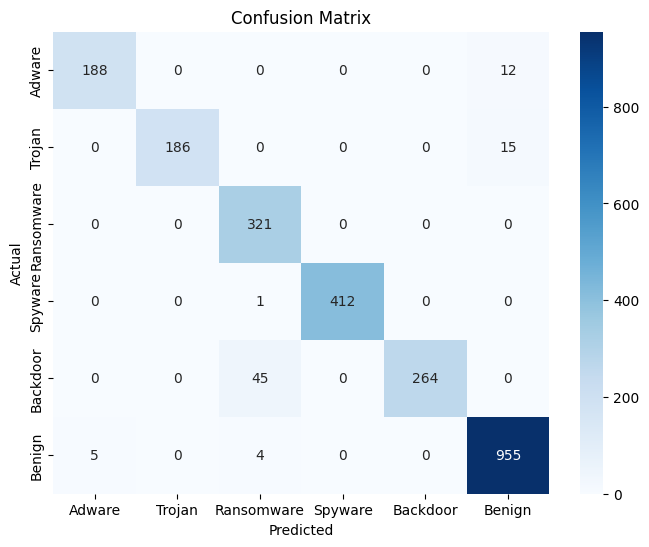

In [ ]:
labels = [
    'Adware',
    'Trojan',
    'Ransomware',
    'Spyware',
    'Backdoor',
    'Benign'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       200
           1       1.00      0.93      0.96       201
           2       0.87      1.00      0.93       321
           3       1.00      1.00      1.00       413
           4       1.00      0.85      0.92       309
           5       0.97      0.99      0.98       964

    accuracy                           0.97      2408
   macro avg       0.97      0.95      0.96      2408
weighted avg       0.97      0.97      0.97      2408



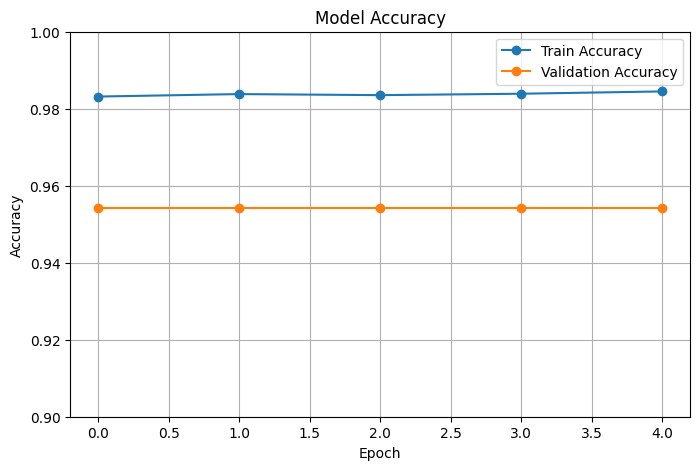

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Model Accuracy')

plt.ylim(0.90, 1.00)

plt.grid(True)

plt.legend()

plt.show()

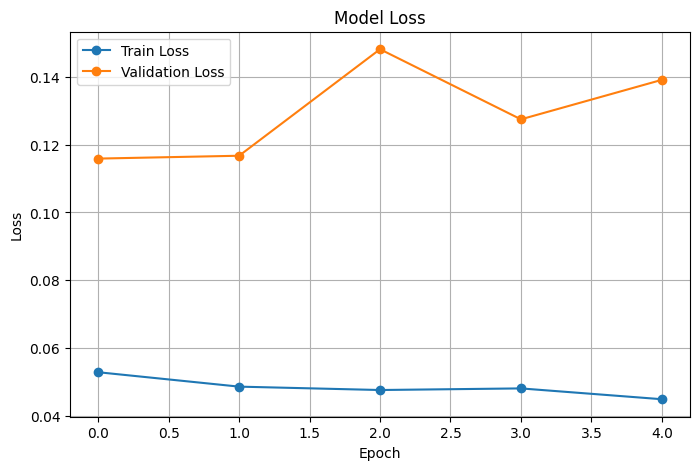

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    marker='o',
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='o',
    label='Validation Loss'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Model Loss')

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
model_no_dp = Sequential()

model_no_dp.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train_smote.shape[1],)
))

model_no_dp.add(Dense(
    32,
    activation='relu'
))

model_no_dp.add(Dense(
    6,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_no_dp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_no_dp = model_no_dp.fit(
    X_train_smote,
    y_train_smote,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9146 - loss: 0.2989 - val_accuracy: 0.9542 - val_loss: 0.1680
Epoch 2/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9850 - loss: 0.0466 - val_accuracy: 0.9542 - val_loss: 0.1450
Epoch 3/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - loss: 0.0452 - val_accuracy: 0.9542 - val_loss: 0.1386
Epoch 4/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9851 - loss: 0.0437 - val_accuracy: 0.9542 - val_loss: 0.1263
Epoch 5/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.0409 - val_accuracy: 0.9542 - val_loss: 0.1383


In [ ]:
loss_no_dp, accuracy_no_dp = model_no_dp.evaluate(
    X_test,
    y_test
)

print("Accuracy WITHOUT Privacy:", accuracy_no_dp)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9593 - loss: 5.4047
Accuracy WITHOUT Privacy: 0.9626246094703674


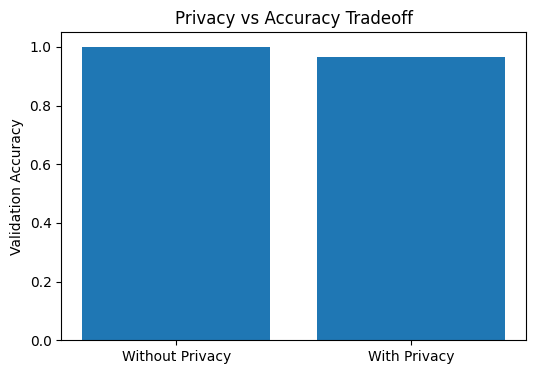

In [ ]:
models = ['Without Privacy', 'With Privacy']

accuracies = [1.00, 0.9657]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.ylabel('Validation Accuracy')

plt.title('Privacy vs Accuracy Tradeoff')

plt.show()

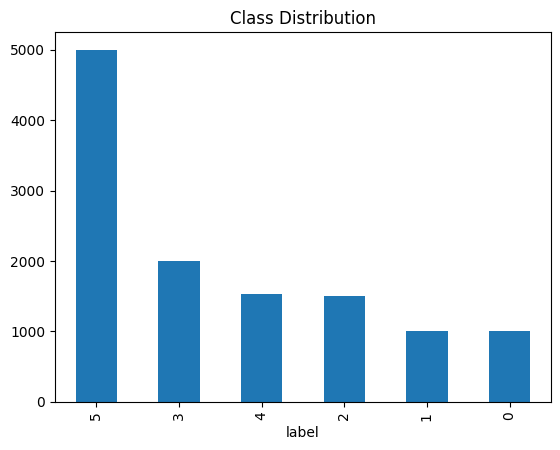

In [ ]:
y.value_counts().plot(kind='bar')

plt.title('Class Distribution')

plt.show()

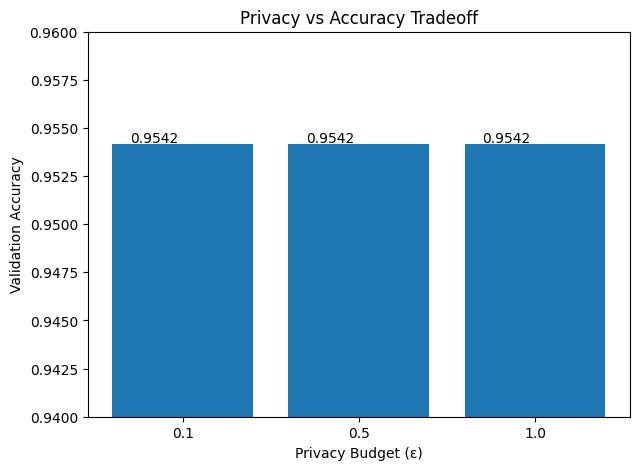

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    ['0.1', '0.5', '1.0'],
    epsilon_results
)

plt.xlabel('Privacy Budget (ε)')

plt.ylabel('Validation Accuracy')

plt.title('Privacy vs Accuracy Tradeoff')

plt.ylim(0.94, 0.96)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + 0.1,
        yval + 0.0001,
        round(yval, 4)
    )

plt.show()

In [ ]:
import time

start = time.time()

history = model.fit(
    X_train_noisy,
    y_train_smote,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

end = time.time()

print("Training Time:", end - start)

Epoch 1/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 5.1832e-04
Epoch 2/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.9992 - val_loss: 0.0061
Epoch 3/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 7.8704e-05
Epoch 4/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 5.4761e-05
Epoch 5/5
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9991 - loss: 0.0031 - val_accuracy: 1.0000 - val_loss: 3.6259e-04
Training Time: 7.275793552398682
